# **XÂY DỰNG & TỐI ƯU MÔ HÌNH HỌC MÁY** 

## <div style="background: linear-gradient(90deg, #002f6c 0%, #0d47a1 40%, #e1f5fe 100%); color: white; padding: 12px 25px; border-left: 10px solid #001633; border-radius: 15px; font-size: 0.85em; display: inline-block; min-width: 450px; box-shadow: 3px 3px 8px rgba(0,0,0,0.15); font-family: 'Segoe UI', sans-serif;"> I. Mục tiêu </div>
* **So sánh mô hình (Benchmarking):** Đối chiếu hiệu suất giữa XGBoost, LightGBM và CatBoost.
* **Dự báo đa nhiệm:** Triển khai song song bài toán Dự báo Giá và Dự báo Doanh số.
* **Tối ưu hóa & Chẩn đoán:** Áp dụng Early Stopping và phân tích sai số qua biểu đồ Residual Plot.
* **Trích xuất Insight:** Đánh giá Feature Importance để nhận diện các yếu tố then chốt tác động đến kinh doanh.
## <div style="background: linear-gradient(90deg, #002f6c 0%, #0d47a1 40%, #e1f5fe 100%); color: white; padding: 12px 25px; border-left: 10px solid #001633; border-radius: 15px; font-size: 0.85em; display: inline-block; min-width: 450px; box-shadow: 3px 3px 8px rgba(0,0,0,0.15); font-family: 'Segoe UI', sans-serif;"> II. Import thư viện và bộ dữ liệu </div>

In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../'))
from scripts.model_training import (
    load_processed_data, get_model, evaluate_model, 
    plot_advanced_evaluation, plot_feature_importance
)

# Cấu hình giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

## <div style="background: linear-gradient(90deg, #002f6c 0%, #0d47a1 40%, #e1f5fe 100%); color: white; padding: 12px 25px; border-left: 10px solid #001633; border-radius: 15px; font-size: 0.85em; display: inline-block; min-width: 450px; box-shadow: 3px 3px 8px rgba(0,0,0,0.15); font-family: 'Segoe UI', sans-serif;"> III. [BÀI TOÁN 1] - Dự báo giá sản phẩm </div>

### **1. Price Prediction: So sánh & Lựa chọn mô hình**

In [ ]:
# 1. Load dữ liệu bài toán Price
X_train, X_val, X_test, y_train, y_val, y_test = load_processed_data(task='price')

# 2. Danh sách mô hình thử nghiệm
model_names = ['xgboost', 'lightgbm', 'catboost']
comparison_results = []

for name in model_names:
    print(f"⏳ Đang huấn luyện {name} cho Price Prediction...")
    model = get_model(name)
    
    # Huấn luyện 
    if name == 'lightgbm':
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='mae')
    else:
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    
    # Đánh giá
    metrics, y_true, y_pred = evaluate_model(model, X_test, y_test)
    metrics['Model'] = name
    comparison_results.append(metrics)

# 3. Hiển thị bảng so sánh
df_res = pd.DataFrame(comparison_results).set_index('Model')
display(df_res.style.highlight_min(subset=['MAE', 'RMSE'], color='#4c4fa1').highlight_max(subset=['R2'], color="#4c4fa1"))

⏳ Đang huấn luyện xgboost cho Price Prediction...
⏳ Đang huấn luyện lightgbm cho Price Prediction...
⏳ Đang huấn luyện catboost cho Price Prediction...


,MAE,RMSE,R2
Model,,,
xgboost,33430.041638,78656.937099,0.988887
lightgbm,35236.843558,79329.880340,0.989546
catboost,34528.274028,76382.265966,0.989820


#### Nhận xét:
* **Tổng quan:** Cả 3 mô hình đều cực kỳ xuất sắc (R2 xấp xỉ **0.99**), chênh lệch hiệu năng rất nhỏ.
* **XGBoost:** Tốt nhất về **MAE**. Dự báo trung bình sát thực tế nhất trên phần lớn dữ liệu "bình thường".
* **CatBoost:** Tốt nhất về **RMSE** và **R2**. Kiểm soát các điểm ngoại lai và các sai số lớn (phạt nặng) tốt hơn XGBoost.
* **LightGBM:** Xếp cuối trong 3 mô hình ở lần chạy này, nhưng khoảng cách không đáng kể.

**Kết luận:** Nên ưu tiên chọn **CatBoost** để triển khai vì nó mang lại độ ổn định toàn diện và ít bị ảnh hưởng bởi các trường hợp dự đoán sai lệch lớn.

### **2. Phân tích sai số & Đặc trưng**
Chọn biểu đồ catboost để thực hiện đánh giá

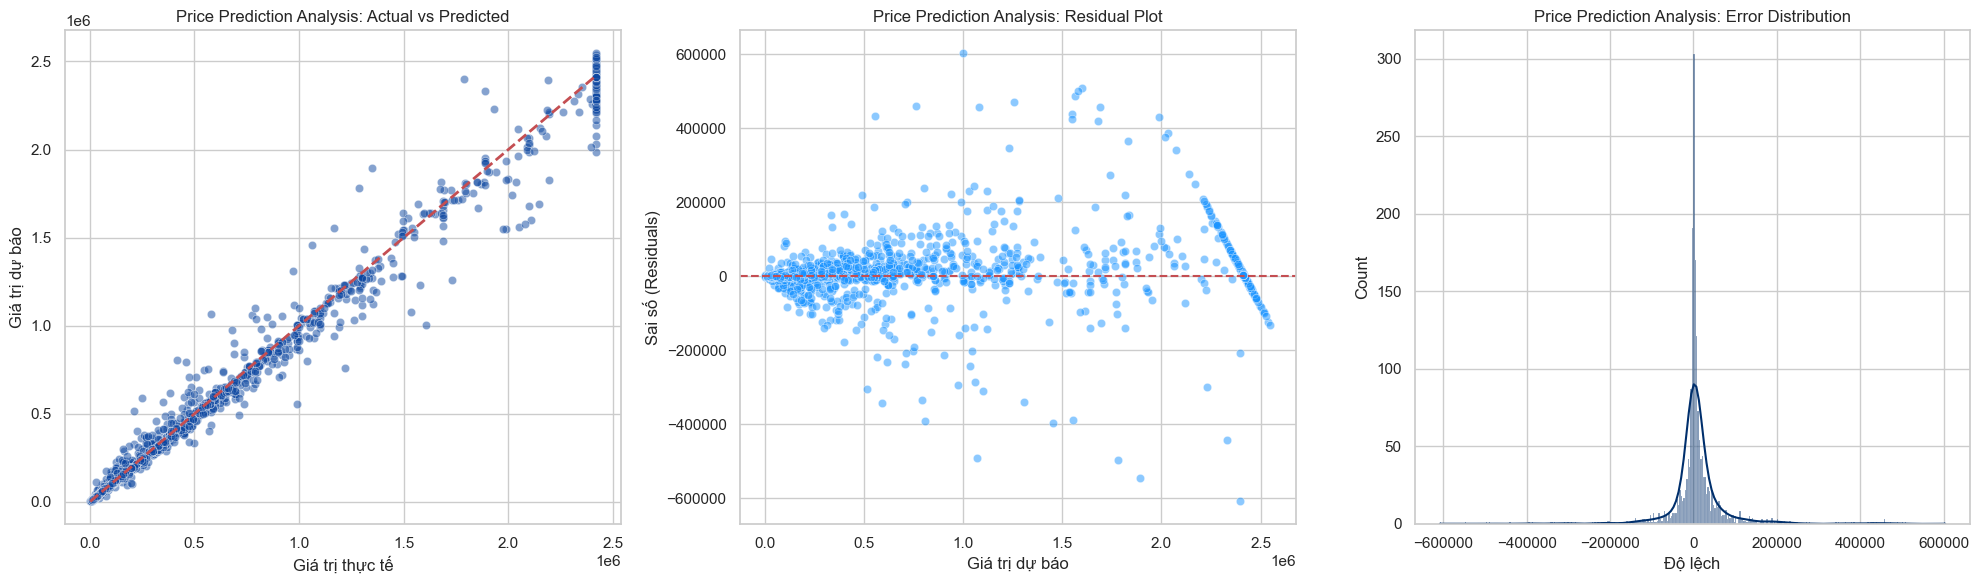

In [ ]:
best_price_model = get_model('catboost')
best_price_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# Tính toán lại kết quả dự báo
metrics, y_true, y_pred = evaluate_model(best_price_model, X_test, y_test)

# Vẽ bộ 3 biểu đồ chuyên nghiệp
plot_advanced_evaluation(y_true, y_pred, title="Price Prediction Analysis")


### Nhận xét
#### 1. Actual vs Predicted (Giá trị thực tế vs Giá trị dự báo)
* **Điểm tích cực:** Phần lớn các điểm dữ liệu bám rất sát vào đường đứt nét màu đỏ (đường lý tưởng y = x). Điều này cho thấy mô hình đã nắm bắt tốt xu hướng chung và có độ chính xác cao ở các mức giá thấp và trung bình.
* **Vấn đề cần lưu ý:** Khi giá trị tăng lên (từ mức 1.5 triệu trở lên), các điểm dữ liệu bắt đầu phân tán rộng ra xa đường màu đỏ. Đặc biệt, có một vệt các điểm dồn lại thành một đường thẳng đứng ở mức giá trị thực tế khoảng 2.4 - 2.5 triệu. Hiện tượng này báo hiệu rằng dữ liệu gốc của bạn có thể đã bị "cắt ngọn" (capped) ở một mức giá trần cố định, nhưng thuật toán học máy lại không có giới hạn đó và vẫn tiếp tục đưa ra các dự đoán cao hơn hoặc thấp hơn mức trần này.

#### 2. Residual Plot (Biểu đồ phần dư / Sai số)
* **Hiện tượng cốt lõi:** Biểu đồ này thể hiện rất rõ đặc tính **phương sai sai số thay đổi (Heteroscedasticity)**. Bạn có thể thấy các điểm phần dư bung rộng ra tạo thành hình "cái phễu" về phía bên phải.
* **Phân tích:** Điều này có nghĩa là khi giá trị dự báo càng lớn, sự không chắc chắn (phương sai) của mô hình càng cao. Mô hình gặp khó khăn trong việc dự báo độ chính xác cho các phân khúc giá cao cấp. Ngoài ra, đường chéo dốc xuống ở sát lề phải một lần nữa khẳng định hiện tượng dữ liệu bị giới hạn (capped): với các mẫu có giá thực tế bị chốt ở mức trần, mô hình dự đoán giá càng cao thì sai số âm càng lớn.

#### 3. Error Distribution (Phân phối độ lệch)
* **Điểm tích cực:** Phân phối của sai số tập trung quanh mức 0 và có hình chuông với đỉnh rất nhọn (high kurtosis). Đây là tín hiệu tốt, cho thấy phần lớn các dự đoán của mô hình có độ lệch cực kỳ nhỏ so với thực tế.
* **Vấn đề cần lưu ý:** Hai phần đuôi của phân phối khá dài (long tails), bao gồm các sai số lên tới mức -600,000 hoặc 600,000. Đây chính là biểu hiện của các điểm ngoại lai (outliers) và hệ quả từ việc dự đoán kém ở các phân khúc giá cao đã phân tích ở trên.


## <div style="background: linear-gradient(90deg, #002f6c 0%, #0d47a1 40%, #e1f5fe 100%); color: white; padding: 12px 25px; border-left: 10px solid #001633; border-radius: 15px; font-size: 0.85em; display: inline-block; min-width: 450px; box-shadow: 3px 3px 8px rgba(0,0,0,0.15); font-family: 'Segoe UI', sans-serif;"> IV. [BÀI TOÁN 2] - Dự báo doanh số </div>

### **1. Sales Forecasting: So sánh và lựa chọn mô hình**

In [ ]:
# 1. Load dữ liệu bài toán Price
X_train, X_val, X_test, y_train, y_val, y_test = load_processed_data(task='sales')

# 2. Danh sách mô hình thử nghiệm
model_names = ['xgboost', 'lightgbm', 'catboost']
comparison_results = []

for name in model_names:
    print(f" Đang huấn luyện {name} cho Price Prediction...")
    model = get_model(name)
    
    # Huấn luyện 
    if name == 'lightgbm':
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='mae')
    else:
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    
    # Đánh giá
    metrics, y_true, y_pred = evaluate_model(model, X_test, y_test)
    metrics['Model'] = name
    comparison_results.append(metrics)

# 3. Hiển thị bảng so sánh
df_res = pd.DataFrame(comparison_results).set_index('Model')
display(df_res.style.highlight_min(subset=['MAE', 'RMSE'], color='#4c4fa1').highlight_max(subset=['R2'], color="#4c4fa1"))

⏳ Đang huấn luyện xgboost cho Price Prediction...
⏳ Đang huấn luyện lightgbm cho Price Prediction...
⏳ Đang huấn luyện catboost cho Price Prediction...


,MAE,RMSE,R2
Model,,,
xgboost,4008.770588,45978.991356,0.811514
lightgbm,3934.303313,45212.547126,0.806624
catboost,3775.152190,45477.769921,0.820331


#### Nhận xét
* **Vấn đề cốt lõi (MAE vs RMSE):** Khoảng cách quá lớn giữa MAE (~3,800) và RMSE (~45,000). Điều này cho thấy dữ liệu có **các điểm đột biến doanh số khổng lồ** (ví dụ: ngày lễ, siêu sale) mà mô hình đang dự đoán sai rất nặng.
* **Tổng quan (R2 ~ 0.80 - 0.82):** Hiệu suất khá tốt, mô hình nắm bắt được hơn 80% xu hướng bán hàng cơ bản.
* **Đánh giá mô hình:**
  * **CatBoost:** Tốt nhất về tổng thể (MAE tốt nhất, R2 cao nhất). Đoán chính xác nhất trong những ngày bán hàng bình thường.
  * **LightGBM:** Bắt ngoại lai tốt nhất (RMSE thấp nhất). Xử lý các đợt bùng nổ doanh số ít bị lỗi nặng nhất.
  * **XGBoost:** Không có điểm vượt trội ở tập dữ liệu này.

### **2. Phân tích kết quả khi huấn luyện với catboost**

⏳ Đang huấn luyện mô hình CatBoost dự báo doanh số...
📊 Kết quả bài toán Sales (Mô hình CatBoost):
   - MAE:  3,775.15 sản phẩm
   - RMSE: 45,477.77 sản phẩm
   - R2 Score: 0.8203

📈 Đang xuất biểu đồ đánh giá sai số cho CatBoost...


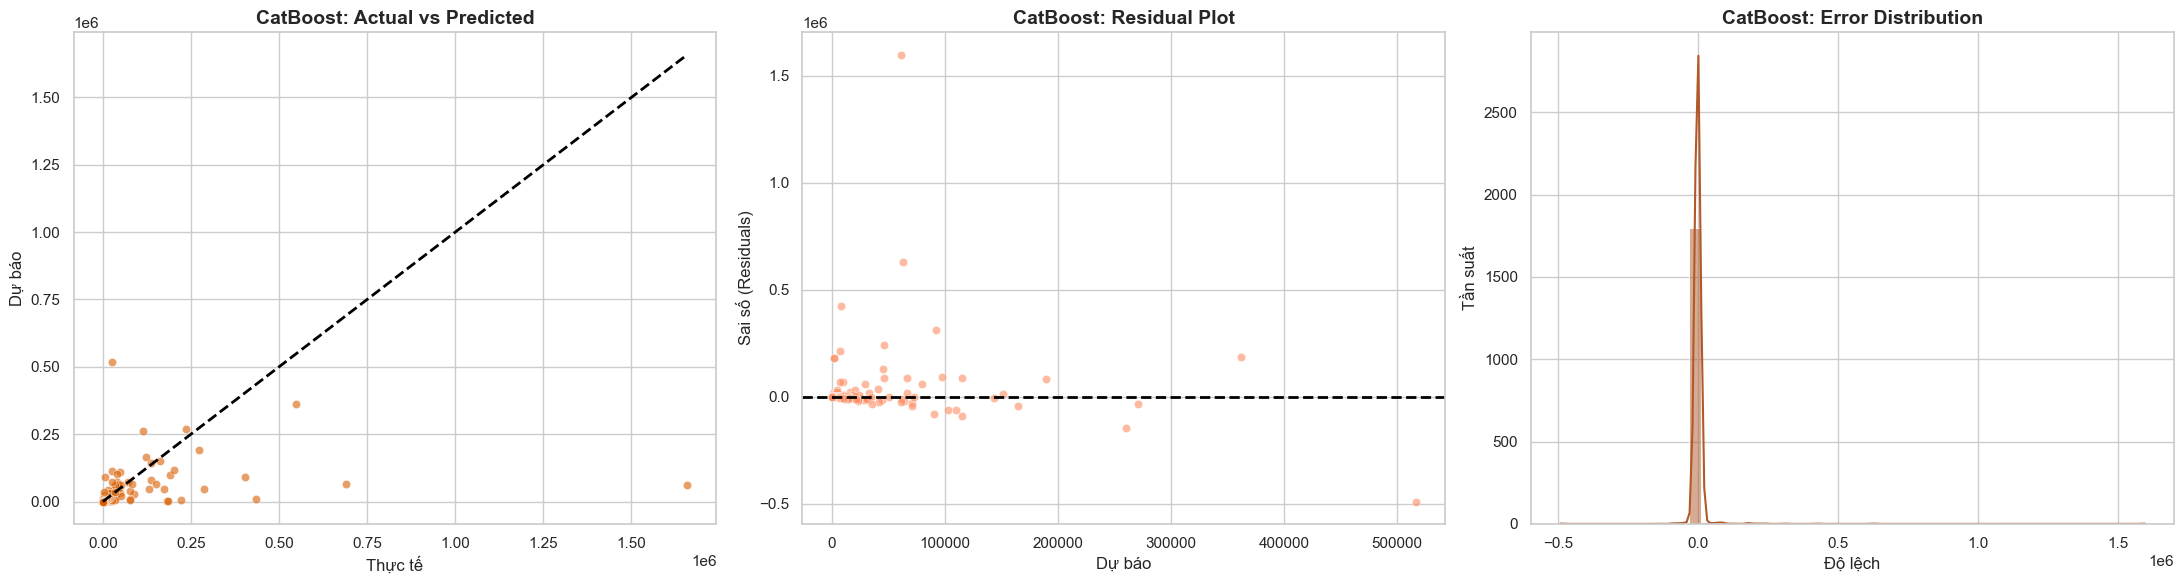

📊 Đang vẽ biểu đồ Feature Importance...


<Figure size 1000x600 with 0 Axes>

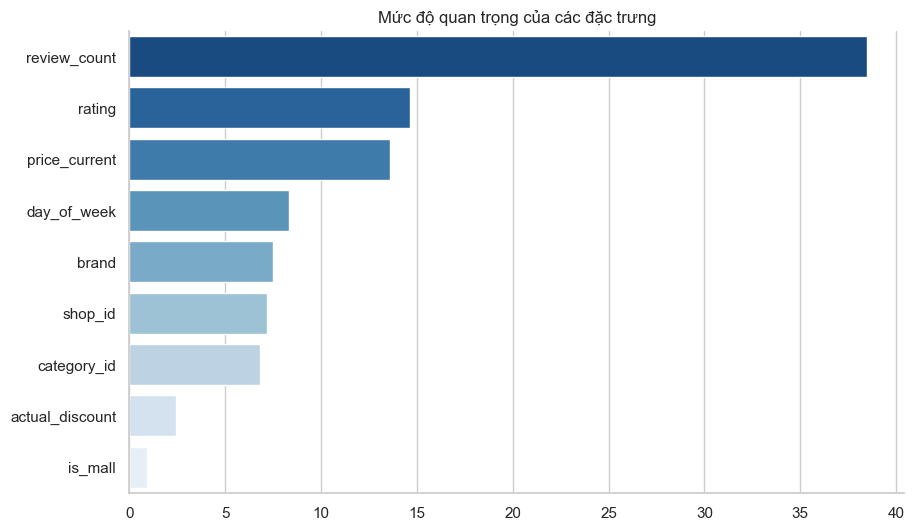

In [ ]:
# Thiết lập style biểu đồ chung
sns.set_theme(style="whitegrid", palette="muted")

# 1. Load dữ liệu bài toán Sales
X_train_s, X_val_s, X_test_s, y_train_s, y_val_s, y_test_s = load_processed_data(task='sales')

# 2. Huấn luyện với mô hình CatBoost
print(" Đang huấn luyện mô hình CatBoost dự báo doanh số...")
sales_model_cat = get_model('catboost')
sales_model_cat.fit(X_train_s, y_train_s, eval_set=[(X_val_s, y_val_s)], verbose=False)

# 3. Đánh giá kết quả
metrics_s_cat, y_true_s_cat, y_pred_s_cat = evaluate_model(sales_model_cat, X_test_s, y_test_s)

print(f" Kết quả bài toán Sales (Mô hình CatBoost):")
print(f"   - MAE:  {metrics_s_cat.get('MAE', 0):,.2f} sản phẩm")
print(f"   - RMSE: {metrics_s_cat.get('RMSE', 0):,.2f} sản phẩm")
print(f"   - R2 Score: {metrics_s_cat.get('R2', 0):.4f}")

# 4. Vẽ 3 biểu đồ chuẩn đoán hồi quy (Actual vs Pred, Residual, Error Dist)
print("\n Đang xuất biểu đồ đánh giá sai số cho CatBoost...")
residuals_s_cat = y_true_s_cat - y_pred_s_cat

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Biểu đồ 1: Actual vs Predicted
sns.scatterplot(x=y_true_s_cat, y=y_pred_s_cat, ax=axes[0], alpha=0.6, color='#d95f02', edgecolor='w') 
min_val = min(np.min(y_true_s_cat), np.min(y_pred_s_cat))
max_val = max(np.max(y_true_s_cat), np.max(y_pred_s_cat))
axes[0].plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', lw=2)
axes[0].set_title("CatBoost: Actual vs Predicted", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Thực tế", fontsize=12)
axes[0].set_ylabel("Dự báo", fontsize=12)

# Biểu đồ 2: Residual Plot
sns.scatterplot(x=y_pred_s_cat, y=residuals_s_cat, ax=axes[1], alpha=0.6, color='#fc8d62', edgecolor='w')
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_title("CatBoost: Residual Plot", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Dự báo", fontsize=12)
axes[1].set_ylabel("Sai số (Residuals)", fontsize=12)

# Biểu đồ 3: Error Distribution
sns.histplot(residuals_s_cat, kde=True, ax=axes[2], color='#b15928', bins=50)
axes[2].set_title("CatBoost: Error Distribution", fontsize=14, fontweight='bold')
axes[2].set_xlabel("Độ lệch", fontsize=12)
axes[2].set_ylabel("Tần suất", fontsize=12)

plt.tight_layout()
plt.show()

# 5. Vẽ biểu đồ Feature Importance
print(" Đang vẽ biểu đồ Feature Importance...")
plt.figure(figsize=(10, 6))
plot_feature_importance(sales_model_cat, X_train_s.columns)

#### Nhận xét:

**1. Hình 1 (Biểu đồ sai số): Bỏ lỡ các "Siêu phẩm"**
* Mô hình dự đoán rất tốt các sản phẩm bán chậm/bình thường, nhưng **dự đoán quá thấp (underpredicting)** các mã hàng có doanh số đột biến. 
* Sự thất bại trước các sản phẩm "hot" này chính là nguyên nhân đẩy RMSE lên mức khổng lồ (> 45,000).

**2. Hình 2 (Mức độ quan trọng): Báo động rò rỉ dữ liệu (Data Leakage)**
* Biến `review_count` (số lượng đánh giá) đang chi phối hoàn toàn kết quả dự báo.
* **Vấn đề:** Khách mua xong mới đánh giá. Việc dùng số đánh giá để đoán số lượng bán ra chỉ là bài toán tỷ lệ nghịch, không phản ánh đúng năng lực dự báo thực sự của mô hình từ các yếu tố gốc (giá cả, thương hiệu, khuyến mãi).